# Stochastic Gradient Descent for Higher Yeild

We want to minimize the impact of the fabrication variations to our final design, and hence increase the yield. We use the same fabrication variation as the 'sensitivity' notebook.

- etch depth (the partial etch goes too far down) $\sim\mathcal{N}(0,5nm)$
- Ovet/underetched (the teeth are too large or small) $\sim\mathcal{N}(0,5nm)$

To do this we will use stochastic gradient decent, sample the noise on the structure on each iteration. The Adam optimizer is well suited for this, so we only need to change the objective function.

In [ ]:
import autograd.numpy as np 
import matplotlib.pyplot as plt

import tidy3d as td
import tidy3d.web as web
td.config.logging_level = "ERROR"

import pickle

from main import (make_sim, get_coupling_efficiency, projection_builder, run_adam, apodized_to_widths,
                    R, r0, initial_fill_factor, grating_period, 
                    etch_depth, to_substrate, N_teeth, n_wl, wl_range,
                    to_substrate)


We set up the new objective fucntion

In [ ]:
# set up random number generator
sigmas = [.005,.005]
rng = np.random.default_rng(seed=42)

# define the objective function
def objective(params,projection=None):
    params_proj = projection(params)
    samples = rng.standard_normal(size=(len(sigmas))) * sigmas
    
    widths = params_proj[:-3]
    r0 = params_proj[N_teeth*2+2]
    etch_depth = params_proj[N_teeth*2+3] + samples[0]
    to_substrate = params_proj[N_teeth*2+4]
    
    sim = make_sim(widths, r0=r0, etch_depth=etch_depth, to_substrate=to_substrate, dilation=samples[1])
    sim_data = web.run(sim, task_name="GC4um_2D_stochastic_opt", verbose=False, path="/data/tidy3d_output/tmp.hdf5"))
    return get_coupling_efficiency(sim_data)[n_wl//2]

Now we run the optimization, it looks very similar to the previous optimization since all the change is in the objective fucntion.

In [ ]:
# define the initial parameters
widths = apodized_to_widths(R=R, initial_fill_factor=initial_fill_factor, N_teeth=N_teeth, grating_period=grating_period)
params0 = np.concatenate([widths, [r0], [etch_depth], [to_substrate]])

# define the projection for enforcing constraints
project, inverse_project = projection_builder()

# run the optimization
history, opt_state = run_adam(params0, project, inverse_project, objective, num_steps=35, learning_rate=0.01, verbose=True)

step = 1
	J = 4.271e-01
	grad_norm = 4.7277e-01
step = 2
	J = 3.315e-01
	grad_norm = 4.6052e-01
step = 3
	J = 3.801e-01
	grad_norm = 5.6102e-01
step = 4
	J = 4.117e-01
	grad_norm = 4.6747e-01
step = 5
	J = 4.409e-01
	grad_norm = 4.4485e-01
step = 6
	J = 3.858e-01
	grad_norm = 4.3662e-01
step = 7
	J = 3.509e-01
	grad_norm = 4.5555e-01
step = 8
	J = 4.806e-01
	grad_norm = 4.2524e-01
step = 9
	J = 4.928e-01
	grad_norm = 4.2995e-01
step = 10
	J = 4.705e-01
	grad_norm = 4.1381e-01
step = 11
	J = 4.888e-01
	grad_norm = 4.3222e-01
step = 12
	J = 5.026e-01
	grad_norm = 4.0619e-01
step = 13
	J = 4.824e-01
	grad_norm = 5.0145e-01
step = 14
	J = 4.815e-01
	grad_norm = 4.8615e-01
step = 15
	J = 4.825e-01
	grad_norm = 5.0939e-01
step = 16
	J = 5.626e-01
	grad_norm = 4.3603e-01
step = 17
	J = 5.354e-01
	grad_norm = 4.8616e-01
step = 18
	J = 4.685e-01
	grad_norm = 5.5889e-01
step = 19
	J = 5.657e-01
	grad_norm = 4.3668e-01
step = 20
	J = 4.659e-01
	grad_norm = 6.4843e-01
step = 21
	J = 5.330e-01
	gra

## 50nm minimum

In [8]:
widths = apodized_to_widths(R=R, initial_fill_factor=initial_fill_factor)
params0 = np.concatenate([widths, [r0], [etch_depth], [to_substrate]])
#params0 = project(history["params"][-1])
project, inverse_project = projection_builder()

history, opt_state = run_adam(params0, project, inverse_project, objective, num_steps=70, learning_rate=0.005, verbose=True)

step = 1
	J = 4.849e-01
	grad_norm = 7.7232e-01
step = 2
	J = 4.908e-01
	grad_norm = 6.0016e-01
step = 3
	J = 4.972e-01
	grad_norm = 5.9135e-01
step = 4
	J = 5.136e-01
	grad_norm = 3.5984e-01
step = 5
	J = 4.964e-01
	grad_norm = 2.9322e-01
step = 6
	J = 5.080e-01
	grad_norm = 2.6253e-01
step = 7
	J = 5.213e-01
	grad_norm = 4.6184e-01
step = 8
	J = 5.260e-01
	grad_norm = 2.4707e-01
step = 9
	J = 5.510e-01
	grad_norm = 2.2906e-01
step = 10
	J = 5.381e-01
	grad_norm = 3.4812e-01
step = 11
	J = 4.183e-01
	grad_norm = 1.9650e-01
step = 12
	J = 5.410e-01
	grad_norm = 2.0699e-01
step = 13
	J = 5.444e-01
	grad_norm = 2.3066e-01
step = 14
	J = 5.528e-01
	grad_norm = 2.6444e-01
step = 15
	J = 5.278e-01
	grad_norm = 2.3232e-01
step = 16
	J = 5.137e-01
	grad_norm = 3.3998e-01
step = 17
	J = 5.641e-01
	grad_norm = 2.0943e-01
step = 18
	J = 5.262e-01
	grad_norm = 3.9598e-01
step = 19
	J = 3.902e-01
	grad_norm = 2.0317e-01
step = 20
	J = 5.471e-01
	grad_norm = 5.1385e-01
step = 21
	J = 5.596e-01
	gra

In [9]:
def objective_no_random(params,projection=None):
    params_proj = projection(params)
    
    widths = params_proj[:N_teeth*2+2]
    r0 = params_proj[N_teeth*2+2]
    etch_depth = params_proj[N_teeth*2+3]
    to_substrate = params_proj[N_teeth*2+4]
    
    sim = make_sim(widths, r0=r0, etch_depth=etch_depth, to_substrate=to_substrate, min_steps_per_wvl=30)
    sim_data = web.run(sim, task_name="GC4um_2D_initial_opt", verbose=False)
    return get_coupling_efficiency(sim_data)[n_wl//2]

In [12]:
objective_no_random(inverse_project(np.array(history["params"][-1])),projection=project)

np.float64(0.6352367438181779)

In [13]:
# Save the optimization history to disk in a human-readable JSON file.
with open("data/stochastic_opt_50nm.json", "w") as f:
    json.dump(history, f, indent=2)

## 100 nm minimum 

In [5]:
R100 = 0.02
initial_fill_factor100 = 120/650
r0100 = 1.0
etch_depth100 = 0.087
to_substrate100 = 1.210

widths_bounds100 = (0.1,0.55)

widths100 = apodized_to_widths(R=R100, initial_fill_factor=initial_fill_factor100)
params0100 = np.concatenate([widths100, [r0100], [etch_depth100], [to_substrate100]])
project100, inverse_project100 = projection_builder(widths_bounds=widths_bounds100)

history, opt_state = run_adam(params0100, project100, inverse_project100, objective, num_steps=70, learning_rate=0.005, verbose=True)

step = 1
	J = 2.106e-01
	grad_norm = 9.5775e-01
step = 2
	J = 3.890e-01
	grad_norm = 2.2971e-01
step = 3
	J = 4.045e-01
	grad_norm = 2.1942e-01
step = 4
	J = 2.461e-01
	grad_norm = 7.8802e-01
step = 5
	J = 3.822e-01
	grad_norm = 2.1875e-01
step = 6
	J = 3.944e-01
	grad_norm = 2.1444e-01
step = 7
	J = 2.442e-01
	grad_norm = 8.1977e-01
step = 8
	J = 4.024e-01
	grad_norm = 1.8090e-01
step = 9
	J = 3.529e-01
	grad_norm = 3.9224e-01
step = 10
	J = 4.012e-01
	grad_norm = 2.0351e-01
step = 11
	J = 4.008e-01
	grad_norm = 2.4212e-01
step = 12
	J = 3.773e-01
	grad_norm = 2.3254e-01
step = 13
	J = 2.983e-01
	grad_norm = 4.3276e-01
step = 14
	J = 2.864e-01
	grad_norm = 5.4112e-01
step = 15
	J = 4.267e-01
	grad_norm = 1.7541e-01
step = 16
	J = 3.823e-01
	grad_norm = 3.7484e-01
step = 17
	J = 3.913e-01
	grad_norm = 4.5163e-01
step = 18
	J = 3.748e-01
	grad_norm = 4.0072e-01
step = 19
	J = 4.160e-01
	grad_norm = 1.9515e-01
step = 20
	J = 2.964e-01
	grad_norm = 3.1086e-01
step = 21
	J = 4.304e-01
	gra

In [10]:
objective_no_random(inverse_project100(np.array(history["params"][-1])),projection=project100)

np.float64(0.457739410898928)

In [11]:
# Save the optimization history to disk in a human-readable JSON file.
with open("data/stochastic_opt_100nm.json", "w") as f:
    json.dump(history, f, indent=2)

# Look at less teeth 

In [8]:
#set up random number generator
sigmas = [.005,.005,.005]
rng = np.random.default_rng(seed=42)
N_teeth = 6

def objective(params,projection=None,N_teeth=N_teeth):
    params_proj = projection(params)
    samples = rng.standard_normal(size=(len(sigmas))) * sigmas
    
    widths = params_proj[:N_teeth*2+2]
    r0 = params_proj[N_teeth*2+2] +samples[0]
    etch_depth = params_proj[N_teeth*2+3] +samples[1]
    to_substrate = params_proj[N_teeth*2+4]
    
    sim = make_sim(widths, r0=r0, etch_depth=etch_depth, to_substrate=to_substrate, dilation=samples[2], N_teeth=N_teeth, min_steps_per_wvl=30)
    sim_data = web.run(sim, task_name="GC4um_2D_FewTeeth_opt", verbose=False)
    return get_coupling_efficiency(sim_data)[n_wl//2]

In [9]:
with open('/Users/dominic/Desktop/fdtd/testing/PhotonicComponents/GC_4um_3d/data/2d_opt/stochastic_opt_50nm.json', 'r') as f:
    data = json.load(f)

paramsOld = data['params'][-1]
widths = paramsOld[:15*2+2][10:10+N_teeth*2+2]
etch_depth = paramsOld[15*2+3]
to_substrate = paramsOld[15*2+4]

params0 = np.concatenate([widths, [1], [etch_depth], [to_substrate]])
widths_bounds = (0.05, 0.6)
r0_bounds = (0,2)
etch_depth_bounds = (0.05, 0.2)
to_substrate_bounds = (.8,2)
project, inverse_project = projection_builder(widths_bounds=widths_bounds, r0_bounds=r0_bounds, etch_depth_bounds=etch_depth_bounds, to_substrate_bounds=to_substrate_bounds, N_teeth=N_teeth)

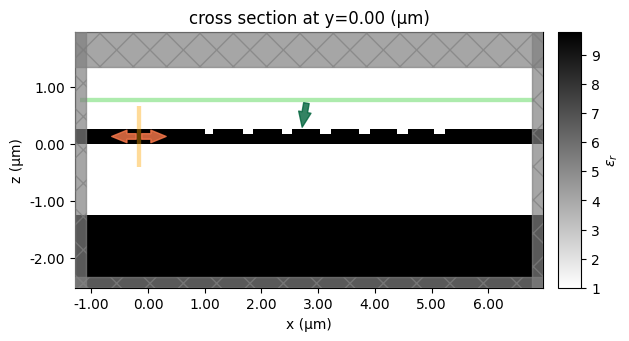

np.float64(0.5973931550573692)

In [6]:
objective(inverse_project(np.array(params0)),projection=project)

In [11]:
# run the optimization
history, opt_state = run_adam(params0, project, inverse_project, objective, num_steps=50, learning_rate=0.0025, verbose=True)

step = 1
	J = 6.360e-01
	grad_norm = 2.9370e-01
step = 2
	J = 6.446e-01
	grad_norm = 2.8285e-01
step = 3
	J = 6.363e-01
	grad_norm = 3.2159e-01
step = 4
	J = 6.097e-01
	grad_norm = 5.7090e-01
step = 5
	J = 6.316e-01
	grad_norm = 3.5612e-01
step = 6
	J = 6.061e-01
	grad_norm = 6.1688e-01
step = 7
	J = 6.368e-01
	grad_norm = 2.9649e-01
step = 8
	J = 6.473e-01
	grad_norm = 2.7898e-01
step = 9
	J = 6.290e-01
	grad_norm = 3.5569e-01
step = 10
	J = 6.346e-01
	grad_norm = 2.5202e-01
step = 11
	J = 6.496e-01
	grad_norm = 3.4561e-01
step = 12
	J = 6.415e-01
	grad_norm = 2.4678e-01
step = 13
	J = 6.419e-01
	grad_norm = 2.5361e-01
step = 14
	J = 6.455e-01
	grad_norm = 2.3105e-01
step = 15
	J = 6.510e-01
	grad_norm = 4.0875e-01
step = 16
	J = 6.539e-01
	grad_norm = 2.7611e-01
step = 17
	J = 6.515e-01
	grad_norm = 2.1939e-01
step = 18
	J = 6.355e-01
	grad_norm = 3.0831e-01
step = 19
	J = 6.321e-01
	grad_norm = 4.2944e-01
step = 20
	J = 6.314e-01
	grad_norm = 4.6616e-01
step = 21
	J = 6.559e-01
	gra

In [12]:
# Save the optimization history to disk in a human-readable JSON file.
with open("data/stochastic_opt_50nm_6teeth.json", "w") as f:
    json.dump(history, f, indent=2)

In [14]:
def objective_no_random(params,projection=None,N_teeth=N_teeth):
    params_proj = projection(params)
    
    widths = params_proj[:N_teeth*2+2]
    r0 = params_proj[N_teeth*2+2]
    etch_depth = params_proj[N_teeth*2+3]
    to_substrate = params_proj[N_teeth*2+4]
    
    sim = make_sim(widths, r0=r0, etch_depth=etch_depth, to_substrate=to_substrate, dilation=0, N_teeth=N_teeth, min_steps_per_wvl=30)
    fig, ax = plt.subplots(1,1)
    sim.plot_eps(y=0,ax=ax)
    plt.tight_layout()
    plt.show()
    sim_data = web.run(sim, task_name="GC4um_2D_FewTeeth_opt", verbose=False)
    return get_coupling_efficiency(sim_data)[n_wl//2]

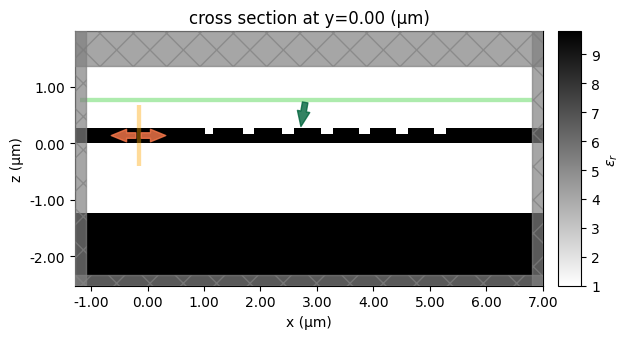

np.float64(0.6710629294653329)

In [16]:
objective_no_random(inverse_project(np.array(history["params"][-1])),projection=project)

In [17]:
print(np.array(history["params"][-1]))

[0.15472438 0.53076993 0.18771608 0.50601878 0.2041058  0.48326561
 0.1992763  0.47021592 0.19971255 0.4569045  0.21308657 0.45651158
 0.20474298 0.43978901 1.01004867 0.11240274 1.23943065]
